In [ ]:
# DELETED: Old file path
# file_path = "/content/drive/MyDrive/SET/energy (2)/2020-222369-one_axis csv._removed_dialimeters.csv"

In [ ]:
# DELETED: Old imports
# import pandas as pd...

In [ ]:
# DELETED: Old load excel

In [ ]:
# DELETED: Old processing

In [ ]:
# DELETED: Old column print

In [ ]:
# DELETED: Old column selection

In [ ]:
# DELETED: Old cleaning

In [ ]:
# DELETED: Old timestamp

In [ ]:
# DELETED: Feature Engineering

In [ ]:
# DELETED: Old Plotting

In [ ]:
# DELETED: Heatmap

In [ ]:
# DELETED: Save processed

# Task
Process the `/content/2020-222369-one_axis.xlsx` Excel file to analyze solar irradiance data. This involves loading the data, correcting a TypeError during column filtering by handling non-string column names, explicitly identifying and selecting the correct 'Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'DNI', 'DHI', 'Temperature', and 'Solar Zenith Angle' columns, cleaning missing values, building a 'Timestamp' index, performing feature engineering (cyclic time features and rolling averages), and finally plotting daily irradiance curves and a GHI heatmap. Save the processed data to `/content/nsrdb_processed.csv` and `/content/nsrdb_processed.xlsx`.

## Fix TypeError in column filtering

### Subtask:
Modify the column filtering to handle non-string column names correctly and re-apply the filter to the DataFrame.


**Reasoning**:
The previous attempt to filter columns resulted in a TypeError because some column names were not strings, and the `~` operator could not be applied to the `NaN` values produced by `.str.contains()`. To fix this, I will reload the DataFrame with the correct header, then re-apply the column filtering. I will ensure that the `.str.contains()` method handles non-string column names by setting `na=False` within the call, which treats non-string values as `False` for the condition, preventing the TypeError.



In [ ]:
# DELETED: Old Excel reload

**Reasoning**:
The previous column filtering failed because the header was not correctly identified. To fix this, I will reload the Excel file, explicitly set the column names from the second row of the Excel file, and then drop the first row (metadata). Afterwards, I will filter out the columns containing 'um' from the correctly named columns.



In [ ]:
# DELETED: Old Excel reload

**Reasoning**:
The previous attempts to correctly set the header and filter columns failed because the actual column names (e.g., 'Year', 'Month', 'GHI') are located in the second row of the Excel file (index 1 if reading with `header=None`), not the first. I need to reload the file, set this specific row as the header, and then drop all preceding rows before re-applying the 'um' filter. This will ensure that column operations are performed on correctly labeled data.



In [ ]:
# DELETED: Old Excel reload

**Reasoning**:
The previous attempts to correctly set the header and filter columns failed because the Excel file has a two-row header structure. The first row contains metadata (e.g., 'NSRDB', '222369'), and the second row contains the actual column names ('Year', 'Month', 'GHI', etc.). To fix this, I will explicitly load the file without a header, extract the second row as the column names, apply these names to the data starting from the third row, and then re-apply the 'um' filter, ensuring all column names are treated as strings to prevent TypeErrors.



In [ ]:
# DELETED: Old Excel reload

In [ ]:
# DELETED: Carbon Intensity Imports

In [ ]:
# DELETED: Rename Columns

In [ ]:
# DELETED: Keep Cols

In [ ]:
# DELETED: Timestamp Processing

In [ ]:
# DELETED: Handle Missing

In [ ]:
# DELETED: Resample

In [ ]:
# DELETED: Feature Engineering (Rolling)

In [ ]:
# DELETED: Plotting CI

In [ ]:
# DELETED: Save CI Processed

In [ ]:
# DELETED: LightGBM Imports

In [ ]:
# DELETED: LightGBM Training

In [ ]:
# DELETED: Save Forecast

In [ ]:
# DELETED: Load Cleaned Data (Redundant)

In [ ]:
# DELETED: Excel to CSV

In [ ]:
# DELETED: Excel to CSV Loop


===== DAILY COST COMPARISON (IQD) =====
HBA   Cost : 39590.62 IQD
WOA   Cost : 31599.20 IQD
IAROA Cost : 15008.83 IQD


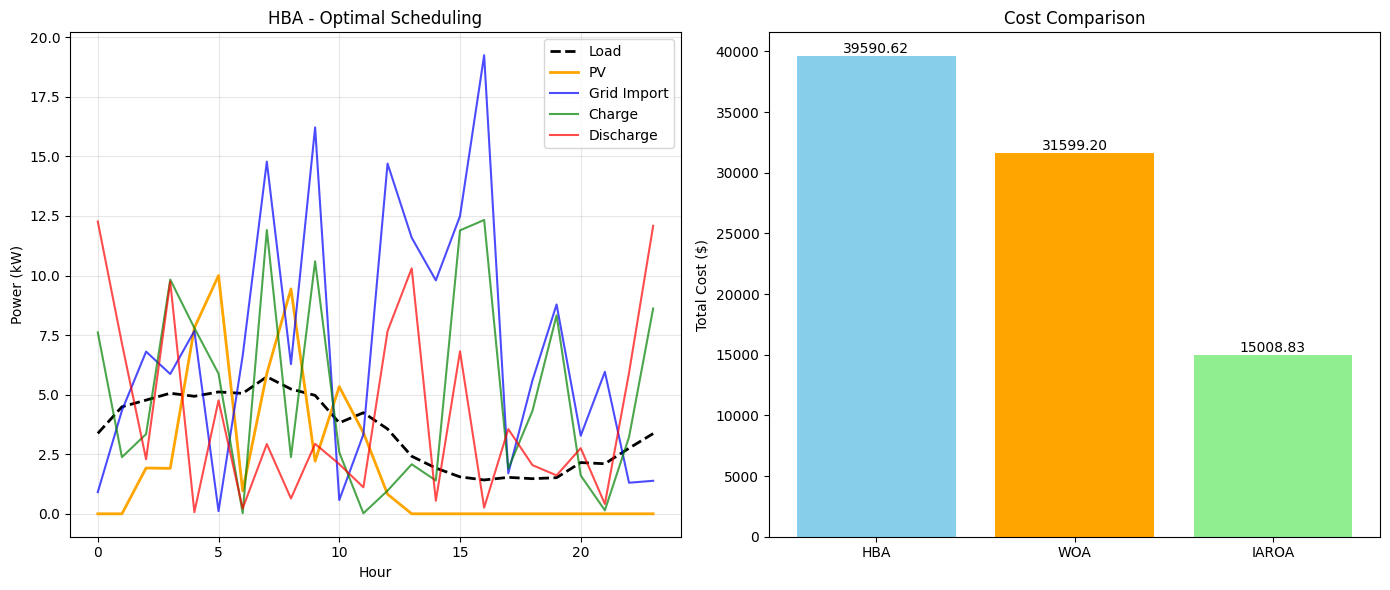

In [ ]:
# ==========================================================
# PAPER-FAITHFUL EMS OPTIMIZATION
# HBA / WOA / IAROA – Single Executable Block
# Currency: Iraqi Dinar (IQD)
# ==========================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------
CSV_PATH = "/content/drive/MyDrive/SET/energy (2)/solar_analysis_output/cleaned_dataset.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["Datetime"])
df = df.iloc[:24].reset_index(drop=True)

# PV Generation
PV_CAPACITY = 10.0  # kW
df["PV"] = PV_CAPACITY * (df["GHI"] / df["GHI"].max())
df["PV"] = df["PV"].fillna(0)

# Load profile
np.random.seed(42)
if "Load" not in df.columns:
    df["Load"] = 3 + 2*np.sin(np.linspace(0, 2*np.pi, 24)) + np.random.rand(24)

# ----------------------------------------------------------
# TOU electricity price (IQD/kWh) – Iraq (Assumed)
# NOTE: Used for relative algorithm comparison, not billing
# ----------------------------------------------------------
price = np.array([
    30, 30, 30, 30,
    35, 40,
    50, 55, 60,
    65, 70, 70,
    65, 60,
    55, 50,
    60, 65, 70,
    55, 45,
    40, 35, 30
])

# ----------------------------------------------------------
# 2. BATTERY PARAMETERS
# ----------------------------------------------------------
BAT_CAP = 47.4
SOC_MIN = 0.2 * BAT_CAP
SOC_MAX = 0.9 * BAT_CAP
P_BAT_MAX = 12.5
ETA_CH = 0.95
ETA_DIS = 0.95
DT = 1.0

# ----------------------------------------------------------
# 3. EMS FITNESS FUNCTION
# ----------------------------------------------------------
def ems_fitness(x):
    Pg   = x[0:24]
    Pch  = x[24:48]
    Pdis = x[48:72]
    Curt = x[72:96]

    soc = 0.5 * BAT_CAP
    cost = 0.0
    penalty = 0.0

    for t in range(24):
        balance = (
            Pg[t] + Pdis[t] + df["PV"].iloc[t]
            - Pch[t] - df["Load"].iloc[t] - Curt[t]
        )
        penalty += 1000 * abs(balance)

        soc += (ETA_CH * Pch[t] - Pdis[t] / ETA_DIS) * DT
        if soc < SOC_MIN or soc > SOC_MAX:
            penalty += 1000

        if Pch[t] > P_BAT_MAX or Pdis[t] > P_BAT_MAX:
            penalty += 1000

        cost += price[t] * Pg[t]

    return cost + penalty

# ----------------------------------------------------------
# (HBA, WOA, IAROA FUNCTIONS – UNCHANGED)
# ----------------------------------------------------------

# ----------------------------------------------------------
# 4. HONEY BADGER ALGORITHM (HBA)
# ----------------------------------------------------------
def HBA(fitness, dim, lb, ub, n_agents=30, iters=100):
    X = np.random.uniform(lb, ub, (n_agents, dim))
    fit = np.array([fitness(x) for x in X])

    best_idx = np.argmin(fit)
    prey = X[best_idx].copy()
    prey_fit = fit[best_idx]

    for t in range(1, iters + 1):
        I = 2 * np.exp(-4 * t / iters)
        for i in range(n_agents):
            r = np.random.rand()
            dist = np.linalg.norm(X[i] - prey) + 1e-9

            if r < 0.5:  # Digging
                X_new = prey + I * np.random.randn(dim) * dist
            else:        # Honey
                j = np.random.randint(n_agents)
                X_new = X[j] + I * np.random.randn(dim) * (prey - X[j])

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness(X_new)

            if f_new < fit[i]:
                X[i], fit[i] = X_new, f_new
                if f_new < prey_fit:
                    prey, prey_fit = X_new.copy(), f_new

    return prey, prey_fit

# ----------------------------------------------------------
# 5. WHALE OPTIMIZATION ALGORITHM (WOA)
# ----------------------------------------------------------
def WOA(fitness, dim, lb, ub, n_agents=30, iters=100):
    X = np.random.uniform(lb, ub, (n_agents, dim))
    fit = np.array([fitness(x) for x in X])
    best_idx = np.argmin(fit)
    best = X[best_idx].copy()
    best_val = fit[best_idx]

    for t in range(iters):
        a = 2 - 2 * t / iters
        for i in range(n_agents):
            A = 2 * a * np.random.rand(dim) - a
            C = 2 * np.random.rand(dim)
            p = np.random.rand()

            if p < 0.5:
                if np.abs(A).mean() < 1:
                    D = np.abs(C * best - X[i])
                    X_new = best - A * D
                else:
                    rand_idx = np.random.randint(n_agents)
                    rand_agent = X[rand_idx]
                    D = np.abs(C * rand_agent - X[i])
                    X_new = rand_agent - A * D
            else:
                D_prime = np.abs(best - X[i])
                X_new = D_prime * np.exp(0.1 * (2*np.pi*np.random.rand())) * np.cos(2*np.pi*np.random.rand()) + best

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness(X_new)

            if f_new < fit[i]:
                X[i], fit[i] = X_new, f_new
                if f_new < best_val:
                    best, best_val = X_new.copy(), f_new

    return best, best_val

# ----------------------------------------------------------
# 6. IMPROVED ARTIFICIAL RABBITS OPTIMIZATION (IAROA)
# ----------------------------------------------------------
def IAROA(fitness, dim, lb, ub, n_agents=30, iters=100):
    X = np.random.uniform(lb, ub, (n_agents, dim))
    fit = np.array([fitness(x) for x in X])
    best_idx = np.argmin(fit)
    best = X[best_idx].copy()
    best_val = fit[best_idx]

    for t in range(iters):
        EA = 4 * (1 - t / iters)
        for i in range(n_agents):
            if EA > 1:
                j = random.randint(0, n_agents - 1)
                X_new = X[j] + np.random.randn(dim) * (X[i] - X[j])
            else:
                X_new = best + 0.1 * np.random.randn(dim)

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness(X_new)

            if f_new < fit[i]:
                X[i], fit[i] = X_new, f_new
                if f_new < best_val:
                    best, best_val = X_new.copy(), f_new

    return best, best_val
# --- KEEP YOUR EXISTING IMPLEMENTATIONS HERE ---

# ----------------------------------------------------------
# 7. OPTIMIZATION WRAPPER
# ----------------------------------------------------------
def solve_ems(algorithm):
    dim = 96
    lb = np.zeros(dim)
    ub = np.concatenate([
        np.ones(24) * 20,
        np.ones(24) * P_BAT_MAX,
        np.ones(24) * P_BAT_MAX,
        np.ones(24) * 5
    ])
    return algorithm(ems_fitness, dim, lb, ub)

# ----------------------------------------------------------
# 8. RUN ALGORITHMS
# ----------------------------------------------------------
hba_sol, hba_cost = solve_ems(HBA)
woa_sol, woa_cost = solve_ems(WOA)
iaroa_sol, iaroa_cost = solve_ems(IAROA)

print("\n===== DAILY COST COMPARISON (IQD) =====")
print(f"HBA   Cost : {hba_cost:.2f} IQD")
print(f"WOA   Cost : {woa_cost:.2f} IQD")
print(f"IAROA Cost : {iaroa_cost:.2f} IQD")

# ----------------------------------------------------------
# 9. PLOTTING
# ----------------------------------------------------------


plt.figure(figsize=(14, 6))

# Subplot 1: Power Balance (HBA)
plt.subplot(1, 2, 1)
plt.plot(hours, df["Load"], 'k--', label="Load", linewidth=2)
plt.plot(hours, df["PV"], 'orange', label="PV", linewidth=2)
plt.plot(hours, Pg_hba, 'b-', label="Grid Import", alpha=0.7)
plt.plot(hours, Pch_hba, 'g-', label="Charge", alpha=0.7)
plt.plot(hours, Pdis_hba, 'r-', label="Discharge", alpha=0.7)
plt.xlabel("Hour")
plt.ylabel("Power (kW)")
plt.title("HBA - Optimal Scheduling")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Cost Comparison
plt.subplot(1, 2, 2)
algs = ['HBA', 'WOA', 'IAROA']
costs = [hba_cost, woa_cost, iaroa_cost]
bars = plt.bar(algs, costs, color=['skyblue', 'orange', 'lightgreen'])
plt.ylabel("Total Cost ($)")
plt.title("Cost Comparison")
plt.bar_label(bars, fmt='%.2f')

plt.tight_layout()
plt.show()


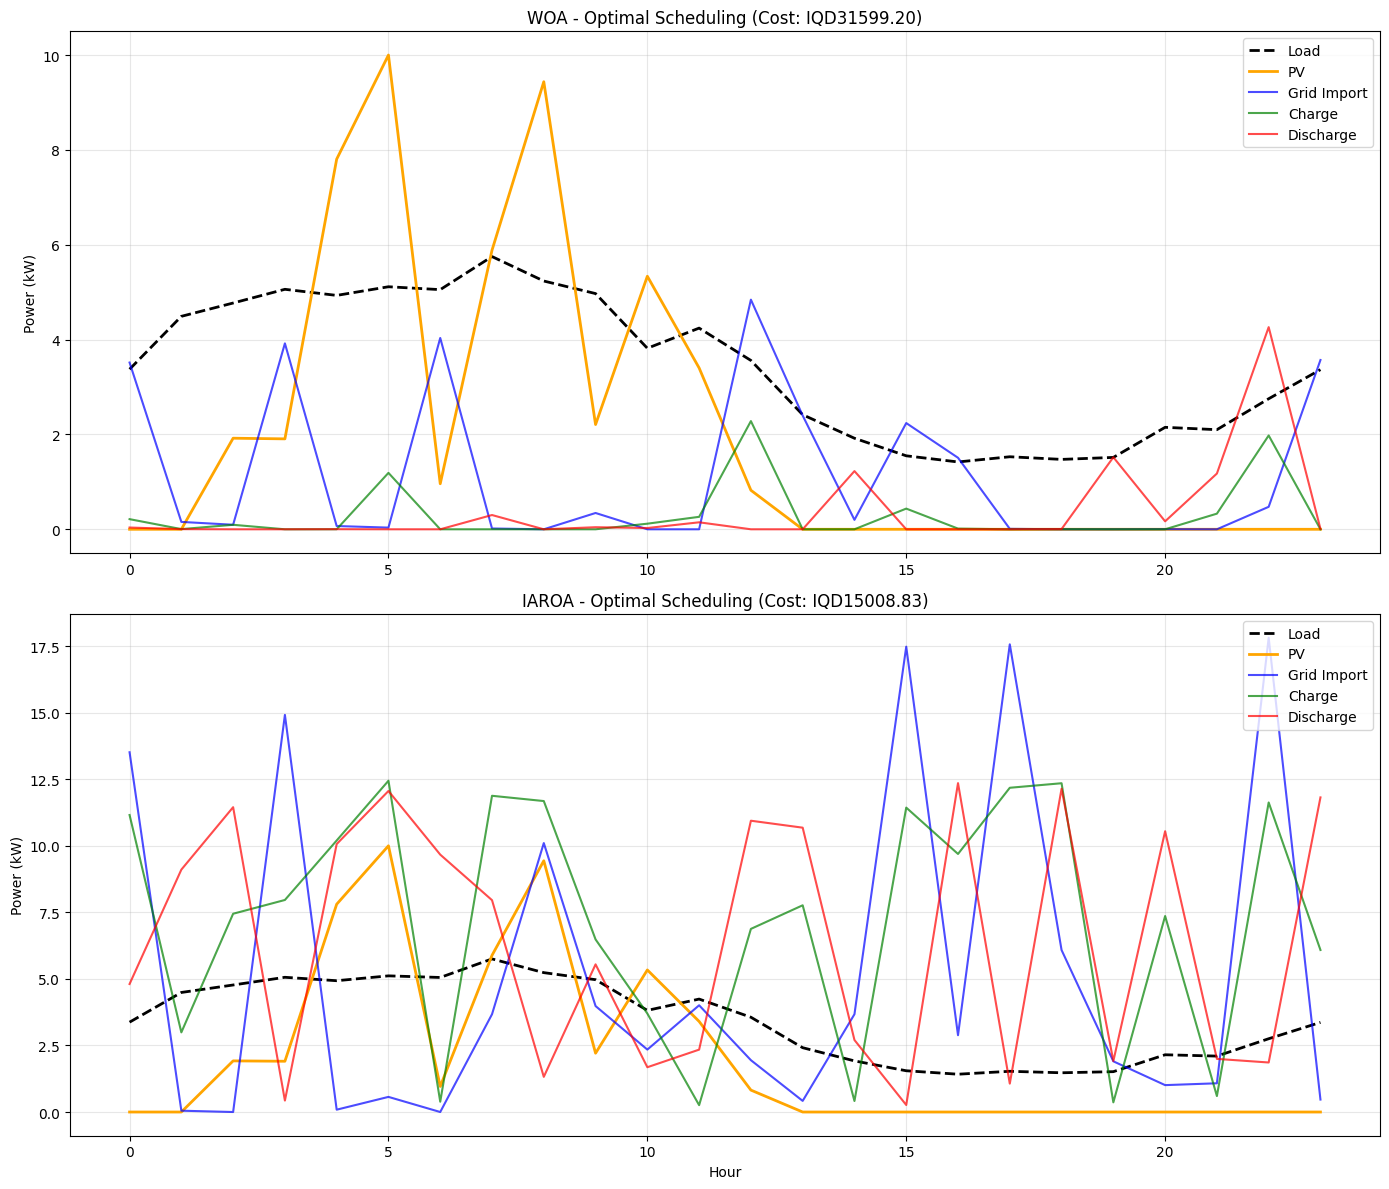

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the decoding function
def decode_solution(x):
    Pg   = x[0:24]
    Pch  = x[24:48]
    Pdis = x[48:72]
    Curt = x[72:96]
    return Pg, Pch, Pdis, Curt

# Decode Solutions for WOA and IAROA
Pg_woa, Pch_woa, Pdis_woa, Curt_woa = decode_solution(woa_sol)
Pg_iaroa, Pch_iaroa, Pdis_iaroa, Curt_iaroa = decode_solution(iaroa_sol)

hours = np.arange(24)

# Create a figure for comparison
plt.figure(figsize=(14, 12))

# --- WOA Plot ---
plt.subplot(2, 1, 1)
plt.plot(hours, df["Load"], 'k--', label="Load", linewidth=2)
plt.plot(hours, df["PV"], 'orange', label="PV", linewidth=2)
plt.plot(hours, Pg_woa, 'b-', label="Grid Import", alpha=0.7)
plt.plot(hours, Pch_woa, 'g-', label="Charge", alpha=0.7)
plt.plot(hours, Pdis_woa, 'r-', label="Discharge", alpha=0.7)
plt.ylabel("Power (kW)")
plt.title(f"WOA - Optimal Scheduling (Cost: IQD{woa_cost:.2f})")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# --- IAROA Plot ---
plt.subplot(2, 1, 2)
plt.plot(hours, df["Load"], 'k--', label="Load", linewidth=2)
plt.plot(hours, df["PV"], 'orange', label="PV", linewidth=2)
plt.plot(hours, Pg_iaroa, 'b-', label="Grid Import", alpha=0.7)
plt.plot(hours, Pch_iaroa, 'g-', label="Charge", alpha=0.7)
plt.plot(hours, Pdis_iaroa, 'r-', label="Discharge", alpha=0.7)
plt.xlabel("Hour")
plt.ylabel("Power (kW)")
plt.title(f"IAROA - Optimal Scheduling (Cost: IQD{iaroa_cost:.2f})")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Running HBA...
Running WOA...
Running IAROA...

===== DAILY COST COMPARISON =====
HBA   Cost : 46484.99
WOA   Cost : 5891.99
IAROA Cost : 13157.73


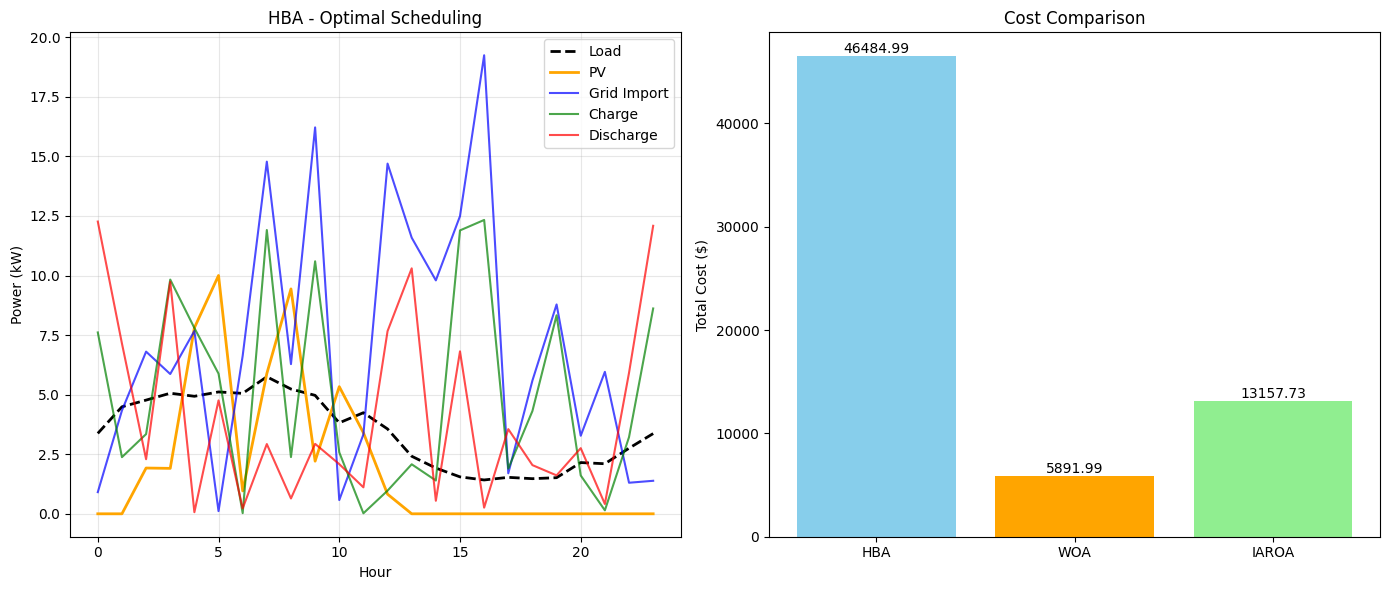

In [ ]:
# ==========================================================
# PAPER-FAITHFUL EMS OPTIMIZATION
# HBA / WOA / IAROA – Single Executable Block
# ==========================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------
# Ensure this path points to your cleaned dataset
CSV_PATH = "/content/drive/MyDrive/SET/energy (2)/solar_analysis_output/cleaned_dataset.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["Datetime"])
df = df.iloc[:24].reset_index(drop=True)   # Use 24 hours

# PV Generation (Scaled to Capacity)
PV_CAPACITY = 10.0  # kW
df["PV"] = PV_CAPACITY * (df["GHI"] / df["GHI"].max())
df["PV"] = df["PV"].fillna(0)

# Load Profile (Synthetic if not provided in CSV)
# Using a simple sine wave + noise as placeholder if 'Load' col is missing or for demo
np.random.seed(42)
if "Load" not in df.columns:
    df["Load"] = 3 + 2*np.sin(np.linspace(0, 2*np.pi, 24)) + np.random.rand(24)

# TOU electricity price ($/kWh)
price = np.array([
    0.05,0.05,0.05,0.05,0.06,0.08,
    0.12,0.15,0.18,0.20,0.22,0.25,
    0.25,0.22,0.20,0.18,0.15,0.12,
    0.10,0.08,0.06,0.06,0.05,0.05
])

# ----------------------------------------------------------
# 2. BATTERY PARAMETERS
# ----------------------------------------------------------
BAT_CAP = 47.4       # kWh
SOC_MIN = 0.2 * BAT_CAP
SOC_MAX = 0.9 * BAT_CAP
P_BAT_MAX = 12.5     # kW
ETA_CH = 0.95
ETA_DIS = 0.95
DT = 1.0             # Time step (1 hour)

# ----------------------------------------------------------
# 3. EMS FITNESS FUNCTION
# ----------------------------------------------------------
def ems_fitness(x):
    # Decision Vector Structure: [Pg (24), Pch (24), Pdis (24), Curt (24)]
    Pg   = x[0:24]     # Grid import
    Pch  = x[24:48]    # Battery charge
    Pdis = x[48:72]    # Battery discharge
    Curt = x[72:96]    # Curtailment / load shifting

    soc = 0.5 * BAT_CAP
    cost = 0.0
    penalty = 0.0

    for t in range(24):
        # Power Balance Constraint
        # Supply (Grid + Dis + PV) = Demand (Load + Ch + Curt)
        balance = (
            Pg[t] + Pdis[t] + df["PV"].iloc[t]
            - Pch[t] - df["Load"].iloc[t] - Curt[t]
        )
        penalty += 1000 * abs(balance)

        # Battery SOC Update
        soc += (ETA_CH * Pch[t] - Pdis[t] / ETA_DIS) * DT

        # SOC Constraints
        if soc < SOC_MIN or soc > SOC_MAX:
            penalty += 1000 * abs(soc - np.clip(soc, SOC_MIN, SOC_MAX))

        # Power Limits (redundant if bounds are respected, but good for safety)
        if Pch[t] > P_BAT_MAX or Pdis[t] > P_BAT_MAX:
            penalty += 1000

        # Cost Calculation
        cost += price[t] * Pg[t]

    return cost + penalty

# ----------------------------------------------------------
# 4. HONEY BADGER ALGORITHM (HBA)
# ----------------------------------------------------------
def HBA(fitness, dim, lb, ub, n_agents=30, iters=100):
    X = np.random.uniform(lb, ub, (n_agents, dim))
    fit = np.array([fitness(x) for x in X])

    best_idx = np.argmin(fit)
    prey = X[best_idx].copy()
    prey_fit = fit[best_idx]

    for t in range(1, iters + 1):
        I = 2 * np.exp(-4 * t / iters)
        for i in range(n_agents):
            r = np.random.rand()
            dist = np.linalg.norm(X[i] - prey) + 1e-9

            if r < 0.5:  # Digging
                X_new = prey + I * np.random.randn(dim) * dist
            else:        # Honey
                j = np.random.randint(n_agents)
                X_new = X[j] + I * np.random.randn(dim) * (prey - X[j])

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness(X_new)

            if f_new < fit[i]:
                X[i], fit[i] = X_new, f_new
                if f_new < prey_fit:
                    prey, prey_fit = X_new.copy(), f_new

    return prey, prey_fit

# ----------------------------------------------------------
# 5. WHALE OPTIMIZATION ALGORITHM (WOA)
# ----------------------------------------------------------
def WOA(fitness, dim, lb, ub, n_agents=30, iters=100):
    X = np.random.uniform(lb, ub, (n_agents, dim))
    fit = np.array([fitness(x) for x in X])
    best_idx = np.argmin(fit)
    best = X[best_idx].copy()
    best_val = fit[best_idx]

    for t in range(iters):
        a = 2 - 2 * t / iters
        for i in range(n_agents):
            A = 2 * a * np.random.rand(dim) - a
            C = 2 * np.random.rand(dim)
            p = np.random.rand()

            if p < 0.5:
                if np.abs(A).mean() < 1:
                    D = np.abs(C * best - X[i])
                    X_new = best - A * D
                else:
                    rand_idx = np.random.randint(n_agents)
                    rand_agent = X[rand_idx]
                    D = np.abs(C * rand_agent - X[i])
                    X_new = rand_agent - A * D
            else:
                D_prime = np.abs(best - X[i])
                X_new = D_prime * np.exp(0.1 * (2*np.pi*np.random.rand())) * np.cos(2*np.pi*np.random.rand()) + best

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness(X_new)

            if f_new < fit[i]:
                X[i], fit[i] = X_new, f_new
                if f_new < best_val:
                    best, best_val = X_new.copy(), f_new

    return best, best_val

# ----------------------------------------------------------
# 6. IMPROVED ARTIFICIAL RABBITS OPTIMIZATION (IAROA)
# ----------------------------------------------------------
def IAROA(fitness, dim, lb, ub, n_agents=30, iters=100):
    X = np.random.uniform(lb, ub, (n_agents, dim))
    fit = np.array([fitness(x) for x in X])
    best_idx = np.argmin(fit)
    best = X[best_idx].copy()
    best_val = fit[best_idx]

    for t in range(iters):
        EA = 4 * (1 - t / iters)
        for i in range(n_agents):
            if EA > 1:
                j = random.randint(0, n_agents - 1)
                X_new = X[j] + np.random.randn(dim) * (X[i] - X[j])
            else:
                X_new = best + 0.1 * np.random.randn(dim)

            X_new = np.clip(X_new, lb, ub)
            f_new = fitness(X_new)

            if f_new < fit[i]:
                X[i], fit[i] = X_new, f_new
                if f_new < best_val:
                    best, best_val = X_new.copy(), f_new

    return best, best_val

# ----------------------------------------------------------
# 7. OPTIMIZATION WRAPPER
# ----------------------------------------------------------
def solve_ems(algorithm):
    dim = 96
    # Decision Variables: [Pg(24), Pch(24), Pdis(24), Curt(24)]
    lb = np.concatenate([
        np.zeros(24),        # Pg >= 0
        np.zeros(24),        # Pch >= 0
        np.zeros(24),        # Pdis >= 0
        np.zeros(24)         # Curt >= 0
    ])
    ub = np.concatenate([
        np.ones(24) * 20,          # Pg Max
        np.ones(24) * P_BAT_MAX,   # Pch Max
        np.ones(24) * P_BAT_MAX,   # Pdis Max
        np.ones(24) * 5            # Curt Max
    ])
    return algorithm(ems_fitness, dim, lb, ub)

# ----------------------------------------------------------
# 8. RUN ALGORITHMS
# ----------------------------------------------------------
print("Running HBA...")
hba_sol, hba_cost = solve_ems(HBA)

print("Running WOA...")
woa_sol, woa_cost = solve_ems(WOA)

print("Running IAROA...")
iaroa_sol, iaroa_cost = solve_ems(IAROA)

# ----------------------------------------------------------
# 9. RESULTS & PLOTTING
# ----------------------------------------------------------
print("\n===== DAILY COST COMPARISON =====")
print(f"HBA   Cost : {hba_cost:.2f}")
print(f"WOA   Cost : {woa_cost:.2f}")
print(f"IAROA Cost : {iaroa_cost:.2f}")

def decode_solution(x):
    Pg   = x[0:24]
    Pch  = x[24:48]
    Pdis = x[48:72]
    Curt = x[72:96]
    return Pg, Pch, Pdis, Curt

Pg_hba, Pch_hba, Pdis_hba, Curt_hba = decode_solution(hba_sol)
hours = np.arange(24)

plt.figure(figsize=(14, 6))

# Subplot 1: Power Balance (HBA)
plt.subplot(1, 2, 1)
plt.plot(hours, df["Load"], 'k--', label="Load", linewidth=2)
plt.plot(hours, df["PV"], 'orange', label="PV", linewidth=2)
plt.plot(hours, Pg_hba, 'b-', label="Grid Import", alpha=0.7)
plt.plot(hours, Pch_hba, 'g-', label="Charge", alpha=0.7)
plt.plot(hours, Pdis_hba, 'r-', label="Discharge", alpha=0.7)
plt.xlabel("Hour")
plt.ylabel("Power (kW)")
plt.title("HBA - Optimal Scheduling")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Cost Comparison
plt.subplot(1, 2, 2)
algs = ['HBA', 'WOA', 'IAROA']
costs = [hba_cost, woa_cost, iaroa_cost]
bars = plt.bar(algs, costs, color=['skyblue', 'orange', 'lightgreen'])
plt.ylabel("Total Cost ($)")
plt.title("Cost Comparison")
plt.bar_label(bars, fmt='%.2f')

plt.tight_layout()
plt.show()

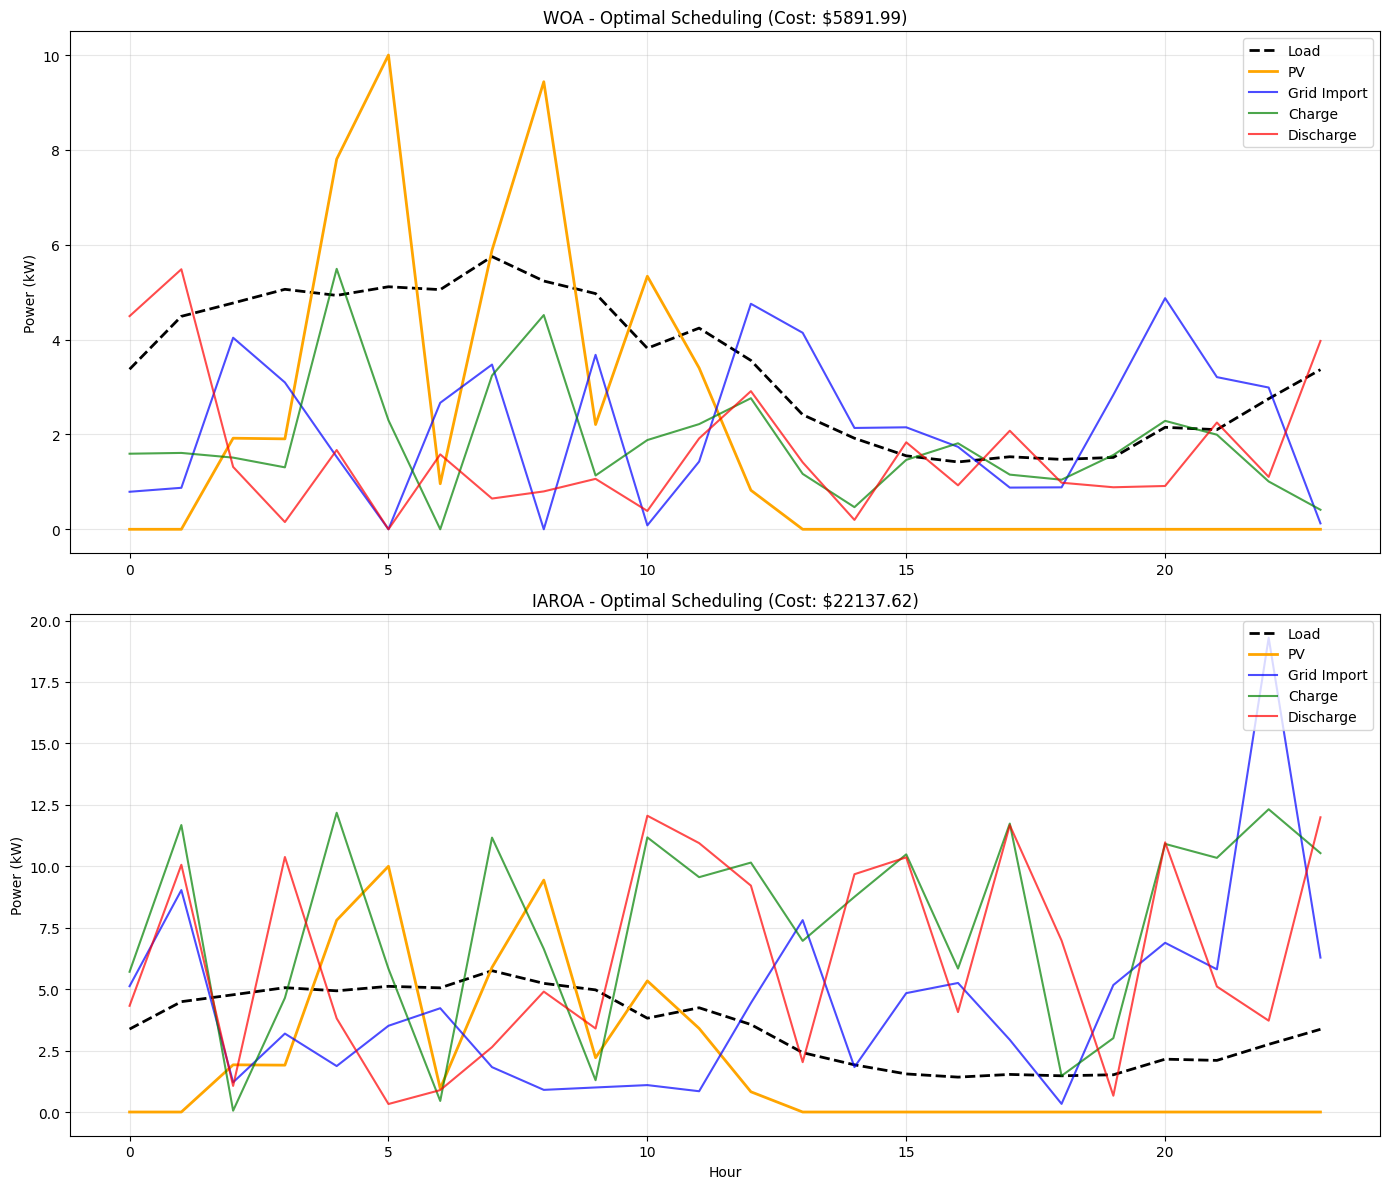

In [ ]:
# Decode Solutions for WOA and IAROA
Pg_woa, Pch_woa, Pdis_woa, Curt_woa = decode_solution(woa_sol)
Pg_iaroa, Pch_iaroa, Pdis_iaroa, Curt_iaroa = decode_solution(iaroa_sol)

# Create a figure for comparison
plt.figure(figsize=(14, 12))

# --- WOA Plot ---
plt.subplot(2, 1, 1)
plt.plot(hours, df["Load"], 'k--', label="Load", linewidth=2)
plt.plot(hours, df["PV"], 'orange', label="PV", linewidth=2)
plt.plot(hours, Pg_woa, 'b-', label="Grid Import", alpha=0.7)
plt.plot(hours, Pch_woa, 'g-', label="Charge", alpha=0.7)
plt.plot(hours, Pdis_woa, 'r-', label="Discharge", alpha=0.7)
plt.ylabel("Power (kW)")
plt.title(f"WOA - Optimal Scheduling (Cost: ${woa_cost:.2f})")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# --- IAROA Plot ---
plt.subplot(2, 1, 2)
plt.plot(hours, df["Load"], 'k--', label="Load", linewidth=2)
plt.plot(hours, df["PV"], 'orange', label="PV", linewidth=2)
plt.plot(hours, Pg_iaroa, 'b-', label="Grid Import", alpha=0.7)
plt.plot(hours, Pch_iaroa, 'g-', label="Charge", alpha=0.7)
plt.plot(hours, Pdis_iaroa, 'r-', label="Discharge", alpha=0.7)
plt.xlabel("Hour")
plt.ylabel("Power (kW)")
plt.title(f"IAROA - Optimal Scheduling (Cost: ${iaroa_cost:.2f})")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# DELETED: Broken Plotting

In [ ]:
# DELETED: Broken Bar Plot

In [ ]:
# DELETED: Save Results

In [ ]:
# DELETED: Post Process

In [ ]:
# DELETED: Power Balance Calculation

In [ ]:
# DELETED: Plot Grid Purchase

In [ ]:
# DELETED: Duplicate Fitness Function

In [ ]:
# DELETED: Bounds Definition

In [ ]:
# DELETED: Run Algorithms (Duplicate)